In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU Count: {torch.cuda.device_count()}")

print("\n--- Current GPU Usage (nvidia-smi) ---")
# This runs the system command to show memory usage per card
!nvidia-smi

PyTorch Version: 2.7.0+cu128
CUDA Available: True
GPU Count: 5

--- Current GPU Usage (nvidia-smi) ---
Fri Feb 20 17:44:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.15              Driver Version: 570.86.15      CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:01:00.0 Off |                    0 |
| N/A   36C    P0             55W /  275W |    1033MiB /  40960MiB |      0%      Default |
|                                    

In [2]:
import torch.backends.cudnn as cudnn

# --- USER CONFIGURATION ---
SELECTED_GPU_INDEX = 1  # <--- CHANGE THIS based on the nvidia-smi output above
# --------------------------

if torch.cuda.is_available():
    device = torch.device(f"cuda:{SELECTED_GPU_INDEX}")
    
    # Enable Benchmark mode for faster training on fixed image sizes
    cudnn.benchmark = True
    print(f"✅ Success! Using GPU: {torch.cuda.get_device_name(SELECTED_GPU_INDEX)} (Index {SELECTED_GPU_INDEX})")
    print(f"✅ cuDNN Benchmark mode: ENABLED")
else:
    device = torch.device("cpu")
    print("⚠️ Warning: CUDA not found. Using CPU.")
    
# Random seed for reproducibility
torch.manual_seed(42)

✅ Success! Using GPU: NVIDIA A100-SXM4-40GB (Index 1)
✅ cuDNN Benchmark mode: ENABLED


In [3]:
# Paths
DATASET_ROOT = "./NIRData"
OUTPUT_DIR = "./predicted_nir_results_attention" # New folder for improved results
MODEL_SAVE_PATH = "best_attention_unet_model.pth"

# Training Settings
BATCH_SIZE = 64      
LEARNING_RATE = 2e-4 
NUM_EPOCHS = 100      # Increased slightly for the scheduler to work effectively
IMG_SIZE = 256       

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output directory set to: {OUTPUT_DIR}")

class CapsicumDataset(Dataset):
    def __init__(self, root_dir, subdir_a, subdir_b, transform=None, return_filename=False):
        self.root_dir = root_dir
        self.dir_a = os.path.join(root_dir, subdir_a)
        self.dir_b = os.path.join(root_dir, subdir_b)
        self.transform = transform
        self.return_filename = return_filename
        
        self.image_filenames = sorted([
            f for f in os.listdir(self.dir_a) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        path_a = os.path.join(self.dir_a, img_name)
        path_b = os.path.join(self.dir_b, img_name)

        # Open Images: RGB (3ch) -> NIR (1ch grayscale)
        img_a = Image.open(path_a).convert("RGB")
        img_b = Image.open(path_b).convert("L") 
        
        if self.transform:
            img_a = self.transform(img_a)
            img_b = self.transform(img_b)

        if self.return_filename:
            return img_a, img_b, img_name
        else:
            return img_a, img_b

# Transforms
transform_pipeline = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Initialize DataLoaders
train_dataset = CapsicumDataset(DATASET_ROOT, 'train_A', 'train_B', transform=transform_pipeline)
val_dataset = CapsicumDataset(DATASET_ROOT, 'val_A', 'val_B', transform=transform_pipeline)
test_dataset = CapsicumDataset(DATASET_ROOT, 'test_A', 'test_B', transform=transform_pipeline, return_filename=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"✅ Data Loaded: Train({len(train_dataset)}), Val({len(val_dataset)}), Test({len(test_dataset)})")

✅ Output directory set to: ./predicted_nir_results_attention
✅ Data Loaded: Train(1291), Val(162), Test(162)


In [4]:
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        # F_g: gate signal (decoder), F_l: skip connection (encoder)
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self):
        super(AttentionUNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.e1 = conv_block(3, 64)
        self.pool = nn.MaxPool2d(2)
        self.e2 = conv_block(64, 128)
        self.e3 = conv_block(128, 256)
        self.e4 = conv_block(256, 512)

        self.b = conv_block(512, 1024)

        # Decoder with Attention Gates
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.d1 = conv_block(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.d2 = conv_block(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.d3 = conv_block(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.d4 = conv_block(128, 64)

        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        c1 = self.e1(x)
        p1 = self.pool(c1)
        c2 = self.e2(p1)
        p2 = self.pool(c2)
        c3 = self.e3(p2)
        p3 = self.pool(c3)
        c4 = self.e4(p3)
        p4 = self.pool(c4)

        b = self.b(p4)

        u1 = self.up1(b)
        x4 = self.att1(g=u1, x=c4) # Attention!
        cat1 = torch.cat((u1, x4), dim=1)
        ud1 = self.d1(cat1)

        u2 = self.up2(ud1)
        x3 = self.att2(g=u2, x=c3) # Attention!
        cat2 = torch.cat((u2, x3), dim=1)
        ud2 = self.d2(cat2)

        u3 = self.up3(ud2)
        x2 = self.att3(g=u3, x=c2) # Attention!
        cat3 = torch.cat((u3, x2), dim=1)
        ud3 = self.d3(cat3)

        u4 = self.up4(ud3)
        x1 = self.att4(g=u4, x=c1) # Attention!
        cat4 = torch.cat((u4, x1), dim=1)
        ud4 = self.d4(cat4)

        return self.out(ud4)

print("✅ Attention U-Net class defined.")

✅ Attention U-Net class defined.


In [5]:
class SSIMLoss(nn.Module):
    def __init__(self):
        super(SSIMLoss, self).__init__()

    def forward(self, img1, img2):
        # Basic SSIM implementation suitable for backprop
        mu1 = nn.functional.avg_pool2d(img1, 3, 1, padding=1)
        mu2 = nn.functional.avg_pool2d(img2, 3, 1, padding=1)
        
        mu1_sq = mu1.pow(2)
        mu2_sq = mu2.pow(2)
        mu1_mu2 = mu1 * mu2
        
        sigma1_sq = nn.functional.avg_pool2d(img1 * img1, 3, 1, padding=1) - mu1_sq
        sigma2_sq = nn.functional.avg_pool2d(img2 * img2, 3, 1, padding=1) - mu2_sq
        sigma12 = nn.functional.avg_pool2d(img1 * img2, 3, 1, padding=1) - mu1_mu2
        
        C1 = 0.01 ** 2
        C2 = 0.03 ** 2
        
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        return 1 - ssim_map.mean()

# Combined Loss Wrapper
class MixedLoss(nn.Module):
    def __init__(self, alpha=0.85):
        super(MixedLoss, self).__init__()
        self.alpha = alpha
        self.l1 = nn.L1Loss()
        self.ssim = SSIMLoss()
        
    def forward(self, pred, target):
        loss = self.alpha * self.l1(pred, target) + (1 - self.alpha) * self.ssim(pred, target)
        return loss

print("✅ Mixed Loss (L1 + SSIM) defined.")

✅ Mixed Loss (L1 + SSIM) defined.


In [6]:
# Initialize Components
model = AttentionUNet().to(device)
criterion = MixedLoss(alpha=0.85).to(device) # 85% L1, 15% SSIM
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print("🚀 Starting Training (Attention U-Net + Mixed Loss)...")

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    running_train_loss = 0.0
    
    # Progress Bar for Training
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)
    
    for rgb, nir in train_loop:
        rgb, nir = rgb.to(device), nir.to(device)
        
        optimizer.zero_grad()
        outputs = model(rgb)
        
        loss = criterion(outputs, nir)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = running_train_loss / len(train_loader)
    
    # --- VALIDATION ---
    model.eval()
    running_val_loss = 0.0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)
    
    with torch.no_grad():
        for rgb, nir in val_loop:
            rgb, nir = rgb.to(device), nir.to(device)
            outputs = model(rgb)
            loss = criterion(outputs, nir)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    
    # Step the scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Store history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Save Best Model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("  💾 Best model saved!")

print("✅ Training Complete.")

🚀 Starting Training (Attention U-Net + Mixed Loss)...


Epoch [1/100] | LR: 0.000200 | Train Loss: 0.2817 | Val Loss: 0.2895
  💾 Best model saved!


Epoch [2/100] | LR: 0.000200 | Train Loss: 0.1152 | Val Loss: 0.2122
  💾 Best model saved!


Epoch [3/100] | LR: 0.000200 | Train Loss: 0.0972 | Val Loss: 0.1171
  💾 Best model saved!


Epoch [4/100] | LR: 0.000199 | Train Loss: 0.0853 | Val Loss: 0.0864
  💾 Best model saved!


...

Epoch [96/100] | LR: 0.000002 | Train Loss: 0.0330 | Val Loss: 0.0352
  💾 Best model saved!


Epoch [97/100] | LR: 0.000001 | Train Loss: 0.0348 | Val Loss: 0.0357


Epoch [98/100] | LR: 0.000001 | Train Loss: 0.0336 | Val Loss: 0.0353


Epoch [99/100] | LR: 0.000001 | Train Loss: 0.0335 | Val Loss: 0.0353


Epoch [100/100] | LR: 0.000001 | Train Loss: 0.0336 | Val Loss: 0.0353
✅ Training Complete.


✅ Loaded best model weights.
⚡ Starting Evaluation on 162 images...


Testing:   0%|          | 0/162 [00:03<?, ?img/s, avg_psnr=25.08, avg_ssim=0.783]

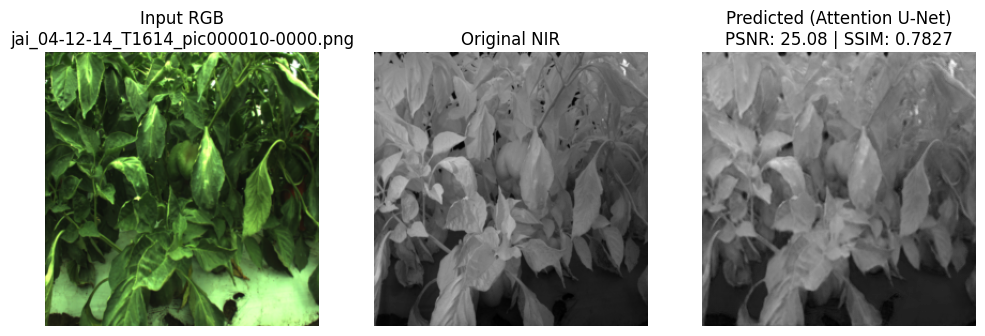

Testing:   1%|          | 1/162 [00:03<10:26,  3.89s/img, avg_psnr=27.08, avg_ssim=0.832]

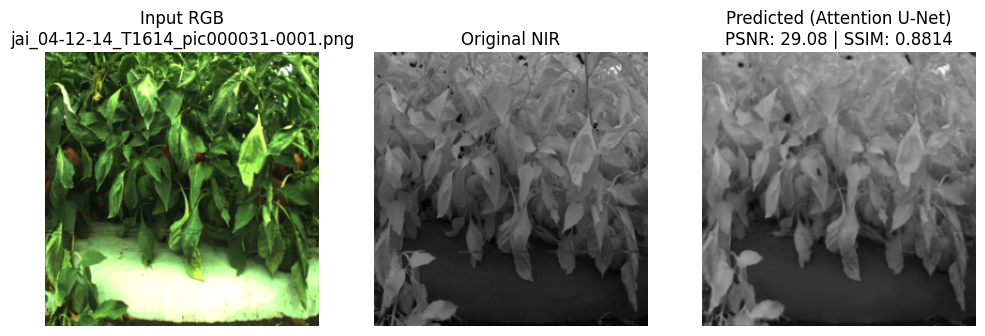

Testing:   1%|          | 2/162 [00:04<04:42,  1.77s/img, avg_psnr=28.14, avg_ssim=0.850]

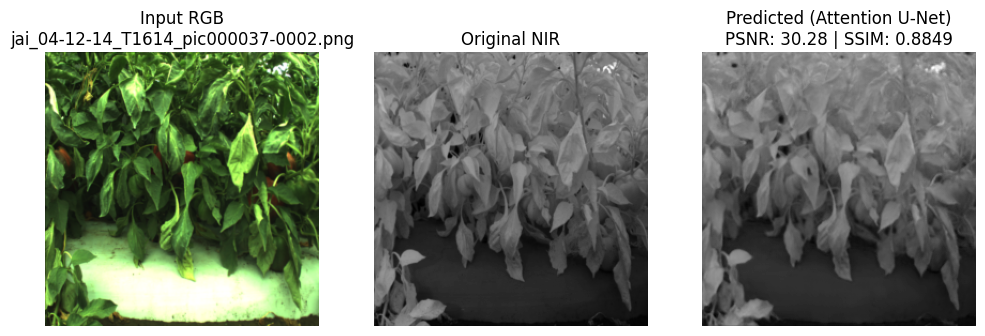

Testing: 100%|██████████| 162/162 [00:18<00:00,  8.76img/s, avg_psnr=29.73, avg_ssim=0.894]


📊 FINAL RESULTS (Attention U-Net)
   Total Images: 162
   Average PSNR: 29.7328 dB
   Average SSIM: 0.8939
   Saved Predicted Images to: ./predicted_nir_results_attention


In [7]:
def visualize_comparison(rgb, real_nir, pred_nir, filename, psnr, ssim):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(rgb.permute(1, 2, 0).cpu().numpy())
    plt.title(f"Input RGB\n{filename}")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(real_nir.squeeze().cpu().numpy(), cmap='gray')
    plt.title("Original NIR")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_nir.squeeze().cpu().numpy(), cmap='gray')
    plt.title(f"Predicted (Attention U-Net)\nPSNR: {psnr:.2f} | SSIM: {ssim:.4f}")
    plt.axis('off')
    
    plt.show()

# Load Best Model
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    print("✅ Loaded best model weights.")
else:
    print("⚠️ Model weights not found, using current model state.")

model.eval()
total_psnr = 0.0
total_ssim = 0.0
count = 0

print(f"⚡ Starting Evaluation on {len(test_loader)} images...")

test_loop = tqdm(test_loader, desc="Testing", unit="img")

with torch.no_grad():
    for rgb, real_nir, filename_tuple in test_loop:
        rgb = rgb.to(device)
        real_nir = real_nir.to(device)
        filename = filename_tuple[0]
        
        pred_nir = model(rgb)
        pred_nir = torch.clamp(pred_nir, 0, 1)
        
        # Save Image
        save_path = os.path.join(OUTPUT_DIR, filename)
        save_image(pred_nir, save_path)
        
        # Calculate Metrics
        real_np = real_nir.squeeze().cpu().numpy()
        pred_np = pred_nir.squeeze().cpu().numpy()
        
        cur_psnr = psnr_metric(real_np, pred_np, data_range=1.0)
        cur_ssim = ssim_metric(real_np, pred_np, data_range=1.0)
        
        total_psnr += cur_psnr
        total_ssim += cur_ssim
        count += 1
        
        test_loop.set_postfix(avg_psnr=f"{total_psnr/count:.2f}", avg_ssim=f"{total_ssim/count:.3f}")

        # Visualize first 3
        if count <= 3:
            visualize_comparison(rgb[0], real_nir[0], pred_nir[0], filename, cur_psnr, cur_ssim)

avg_psnr = total_psnr / count
avg_ssim = total_ssim / count

print("\n" + "="*40)
print(f"📊 FINAL RESULTS (Attention U-Net)")
print(f"   Total Images: {count}")
print(f"   Average PSNR: {avg_psnr:.4f} dB")
print(f"   Average SSIM: {avg_ssim:.4f}")
print(f"   Saved Predicted Images to: {OUTPUT_DIR}")
print("="*40)